# 🏠 Boston Housing Price Prediction (project 10)

## Project Overview
This project uses the **Boston Housing dataset** to build predictive models for estimating 
the median value of owner‑occupied homes (`MEDV`). It is a classic dataset in machine learning 
and statistics, widely used to practice regression techniques.

## Objectives
- Apply **linear regression** (simple and multiple) to predict housing prices.
- Evaluate model performance using **R², MSE, RMSE, and MAPE**.
- Perform **residual analysis** to check model assumptions.
- Interpret regression coefficients to identify **key factors** influencing housing prices 
  (e.g., number of rooms, crime rate, education level).

## Why It Matters
Understanding housing price drivers is crucial in **real estate finance, mortgage risk analysis, 
and investment decision‑making**. This project demonstrates how data science can provide 
insights into property valuation and market dynamics.



## Import Libraraies

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Understanding the Dataset Step 1

### Import Data 

In [4]:
data = pd.read_csv("data/HousingData.csv")
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [5]:
data.shape

(506, 14)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


### Explore Distrubtion of Missing Columns 

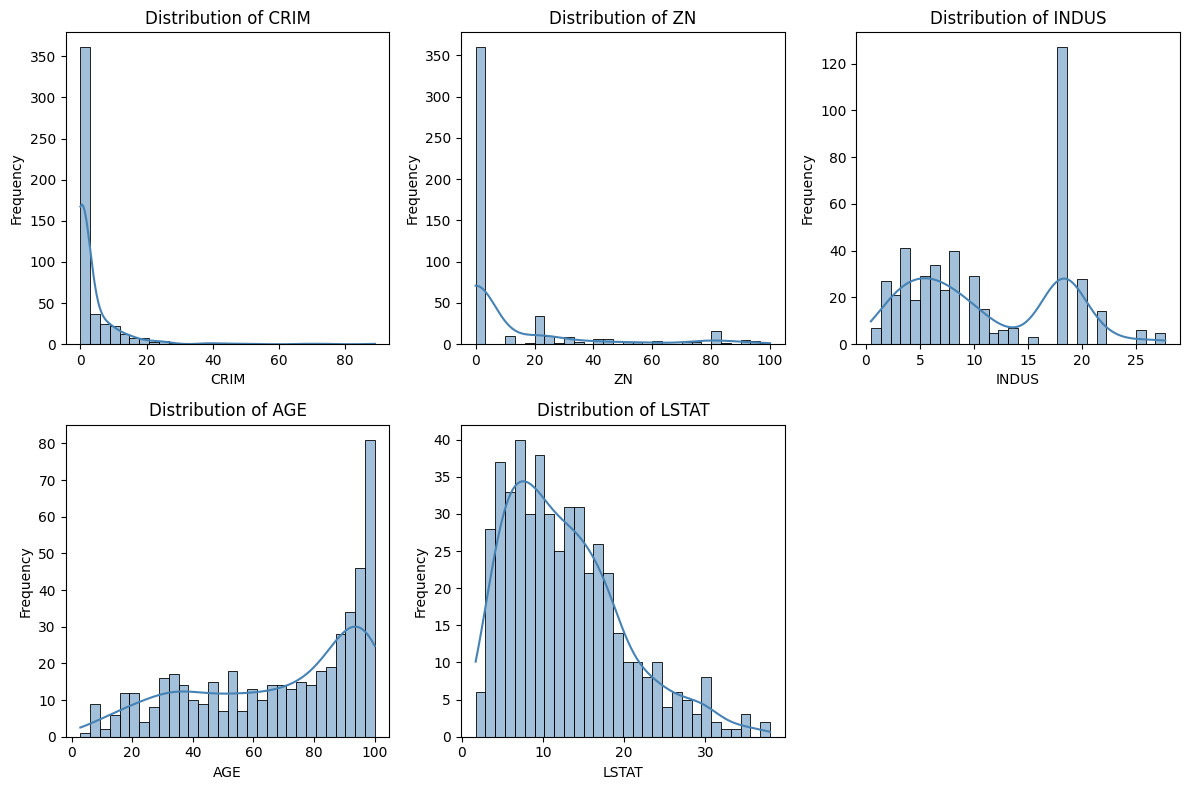

In [7]:
# List of columns with missing values
cols_with_missing = ['CRIM', 'ZN', 'INDUS', 'AGE', 'LSTAT']

# Set up the plot grid
plt.figure(figsize=(12, 8))

for i, col in enumerate(cols_with_missing, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns grid
    sns.histplot(data[col], bins=30, kde=True, color='steelblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### Observations
- 6 columns have missing values: `CRIM`, `ZN`, `INDUS`, `CHAS`, `AGE`, `LSTAT` → each has 486 non-null entries.
- All columns are numeric (`float64` or `int64`) → no type conversion needed.
- `CHAS` is a dummy variable (0/1) → treat as categorical.
- Memory usage is light (55.5 KB) → no performance issues.
- All five continuous variables show skewed or non-normal distributions.
- Median imputation is the safest and most robust choice for all of them.
- For CHAS (dummy), use mode.

### Next Step (Data Preparation Step 2)
- **Data Wrangling**:
  - Impute with median (if patterns exist).
  - Impute categorical column with mode
- **Check for outliers**:
  - Use boxplots for outlier detection
  - Handle outliers
- **Prepare for modeling**:
  - Normalize features if needed.
  - Flag categorical variables (`CHAS`) for encoding if using ML later.

## Data Preparation

### Data Wrangling 

In [8]:
def wrangle_boston_data(df):
    """
    Cleans the Boston Housing dataset by imputing missing values:
    - Median for continuous variables
    - Mode for categorical variables
    Returns a cleaned DataFrame.
    """
    import numpy as np

    # Define columns by type
    continuous_cols = ['CRIM', 'ZN', 'INDUS', 'AGE', 'LSTAT']
    categorical_cols = ['CHAS']

    # Impute continuous columns with median
    for col in continuous_cols:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
    # Impute continuous columns with median
    print("Imputation Done with median")
    # Impute categorical column with mode
    for col in categorical_cols:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
    print("categorical Imputation Done with mode")

    return df
df_wrangled = wrangle_boston_data(data)
df_wrangled

Imputation Done with median
categorical Imputation Done with mode


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,11.43,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,11.43,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


### Outliers Status

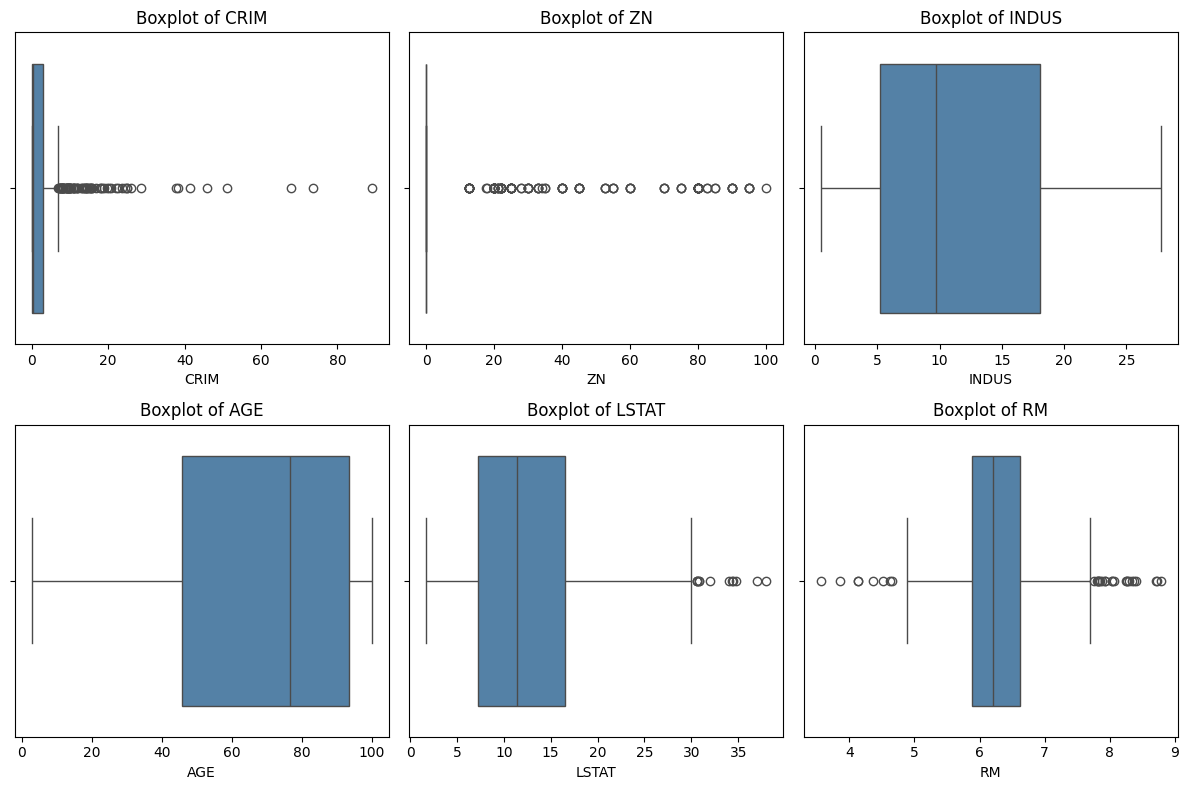

CRIM: 81 outliers
ZN: 126 outliers
INDUS: 0 outliers
AGE: 0 outliers
LSTAT: 12 outliers
RM: 30 outliers


In [9]:
# Continuous columns to check
continuous_cols = ['CRIM', 'ZN', 'INDUS', 'AGE', 'LSTAT', 'RM']

# Boxplots
plt.figure(figsize=(12, 8))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_wrangled[col], color='steelblue')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# IQR method to flag outliers
outliers = {}
for col in continuous_cols:
    Q1 = df_wrangled[col].quantile(0.25)
    Q3 = df_wrangled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = df_wrangled[(df_wrangled[col] < lower_bound) | (df_wrangled[col] > upper_bound)][col]

# Print summary
for col, vals in outliers.items():
    print(f"{col}: {len(vals)} outliers")


**interpretation** : 
- CRIM and ZN are the most problematic, they dominate the outlier count.

- RM and LSTAT have manageable outliers, worth flagging but not necessarily removing.

- INDUS and AGE are clean so no action needed.

### Handle Outliers

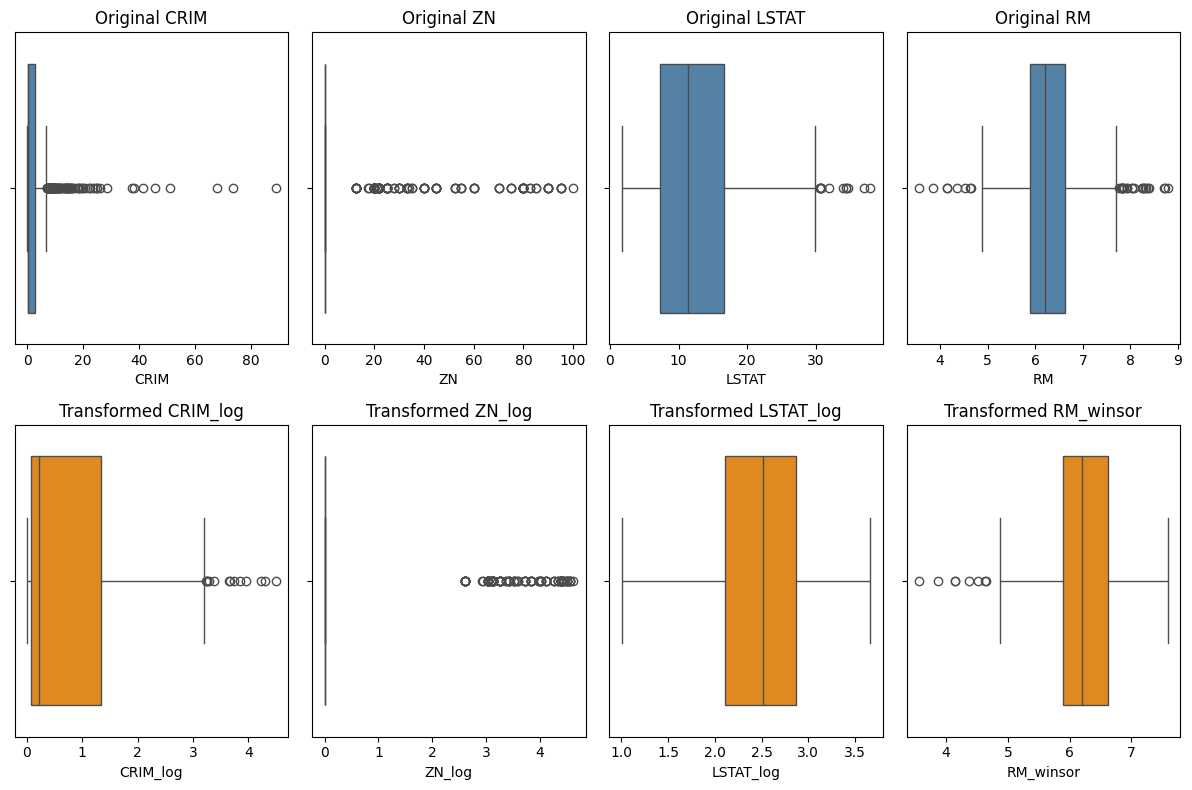

In [10]:

def handle_outliers(df, winsorize_rm=False):
    """
    Preprocesses the Boston Housing dataset by handling outliers:
    - Log transform skewed variables (CRIM, ZN, LSTAT)
    - Optionally winsorize RM (cap at 95th percentile)
    
    Parameters:
        df (DataFrame): Input dataset
        winsorize_rm (bool): If True, cap RM values at 95th percentile
    
    Returns:
        DataFrame: Transformed dataset with new features
    """
    
    df_out = df.copy()
    
    # Log transform skewed variables
    df_out['CRIM_log'] = np.log1p(df_out['CRIM'])
    df_out['ZN_log']   = np.log1p(df_out['ZN'])
    df_out['LSTAT_log'] = np.log1p(df_out['LSTAT'])
    
    # Optional winsorization for RM
    if winsorize_rm:
        upper_bound = df_out['RM'].quantile(0.95)
        df_out['RM_winsor'] = np.where(df_out['RM'] > upper_bound, upper_bound, df_out['RM'])
    else:
        df_out['RM_winsor'] = df_out['RM']
    
    return df_out
    
# Apply outlier handling
df_preprocessed = handle_outliers(df_wrangled, winsorize_rm=True)

# Compare original vs transformed
cols_to_compare = {
    'CRIM': 'CRIM_log',
    'ZN': 'ZN_log',
    'LSTAT': 'LSTAT_log',
    'RM': 'RM_winsor'
}

plt.figure(figsize=(12, 8))

for i, (orig, transformed) in enumerate(cols_to_compare.items(), 1):
    # Original boxplot
    plt.subplot(2, 4, i)
    sns.boxplot(x=df_wrangled[orig], color='steelblue')
    plt.title(f"Original {orig}")
    
    # Transformed boxplot
    plt.subplot(2, 4, i+4)
    sns.boxplot(x=df_preprocessed[transformed], color='darkorange')
    plt.title(f"Transformed {transformed}")

plt.tight_layout()
plt.show()


**interpretation**

- Log transforms successfully compressed skewed variables (CRIM, ZN, LSTAT).

- RM winsorization capped extreme room counts without distorting the core distribution.

- No rows dropped, and the distributions are now stable for regression.

### Correlation Status 

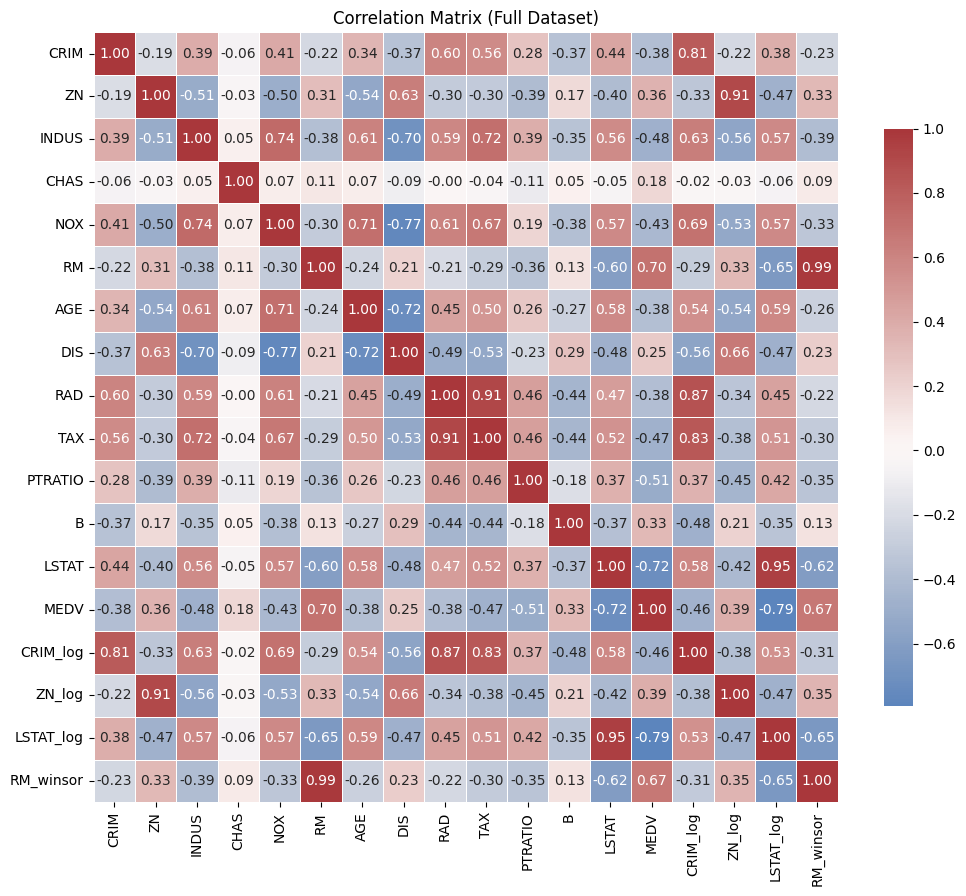

Correlation with MEDV:
 RM           0.695360
RM_winsor    0.669778
ZN_log       0.385122
ZN           0.362292
B            0.333461
DIS          0.249929
CHAS         0.183844
AGE         -0.377572
RAD         -0.381626
CRIM        -0.383895
NOX         -0.427321
CRIM_log    -0.462388
TAX         -0.468536
INDUS       -0.476394
PTRATIO     -0.507787
LSTAT       -0.723093
LSTAT_log   -0.793882
Name: MEDV, dtype: float64


In [11]:
# Assuming df_preprocessed is your dataset after outlier handling
# Correlation matrix
corr_matrix = df_preprocessed.corr()

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            linewidths=.5, cbar_kws={"shrink": .75})
plt.title("Correlation Matrix (Full Dataset)")
plt.show()

# Correlation with target MEDV
corr_with_target = corr_matrix['MEDV'].drop('MEDV').sort_values(ascending=False)
print("Correlation with MEDV:\n", corr_with_target)


**interpretation** :

- LSTAT_log and RM are your strongest predictors — they should definitely be included in your Ridge model.

- Log transforms improved correlation strength and linearity (especially for LSTAT and CRIM).

- RM_winsor is nearly as predictive as raw RM, but safer due to capped outliers.

- ZN_log and PTRATIO are moderately useful.

- Features like CHAS, DIS, and B are weakly correlated — include only if they help in multivariate context.

### Feature Selection

In [12]:
features = ['LSTAT_log', 'RM_winsor', 'ZN_log', 'PTRATIO', 'CRIM_log']

## Build and validate Model

### Train-Test Split

In [16]:
# 2. Train-test split
X = df_preprocessed[features] 
y = df_preprocessed['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Candidate alphas

In [17]:
# 3. Candidate alphas
alphas = [0.01, 0.1, 1, 10, 100]

### Build pipeline

In [18]:
#  Build pipeline: Interaction-only + Scale + RidgeCV
ridge_inter_pipeline = Pipeline([
    ('interactions', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler', StandardScaler()),
    ('ridgecv', RidgeCV(alphas=alphas, scoring='r2'))
])


### Train model

In [19]:
ridge_inter_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('interactions', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",True
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Evaluate

In [20]:
# 6. Best alpha chosen
best_alpha = ridge_inter_pipeline.named_steps['ridgecv'].alpha_
print("Best alpha selected:", best_alpha)

# 7. Evaluate
y_pred = ridge_inter_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Handle MAPE safely (avoid division by zero)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Ridge with Interaction Features (alpha={best_alpha}):")
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"MAPE: {mape:.2f}%")


Best alpha selected: 0.1
Ridge with Interaction Features (alpha=0.1):
R² Score: 0.785
RMSE: 3.971
MAE: 2.473
MAPE: 12.23%


### Save The Model 

In [21]:
import joblib

joblib.dump(ridge_inter_pipeline, "ridge_model.pkl")


['ridge_model.pkl']

### Scatter plot of actual vs predicted

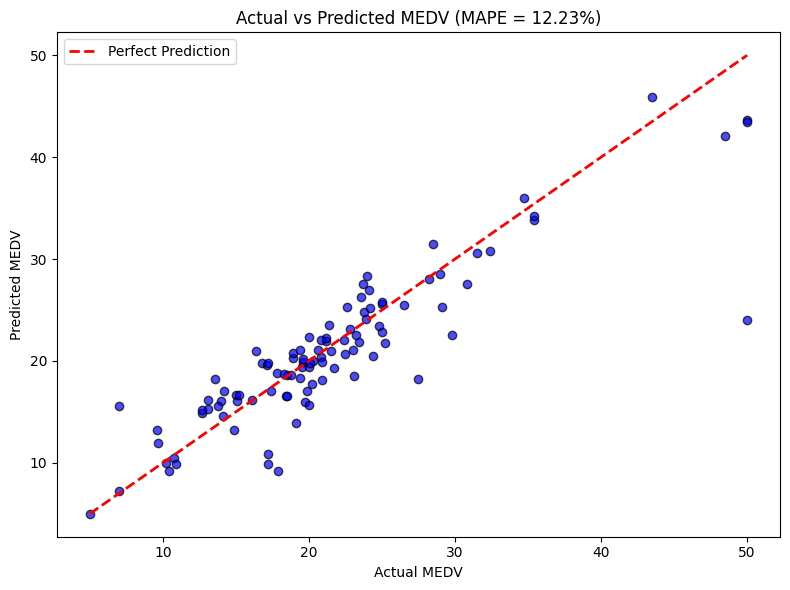

In [22]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue", edgecolor="k")

# 45° reference line (perfect predictions)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label="Perfect Prediction")

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title(f"Actual vs Predicted MEDV (MAPE = {mape:.2f}%)")
plt.legend()
plt.tight_layout()
plt.show()


### Analyze Residual 

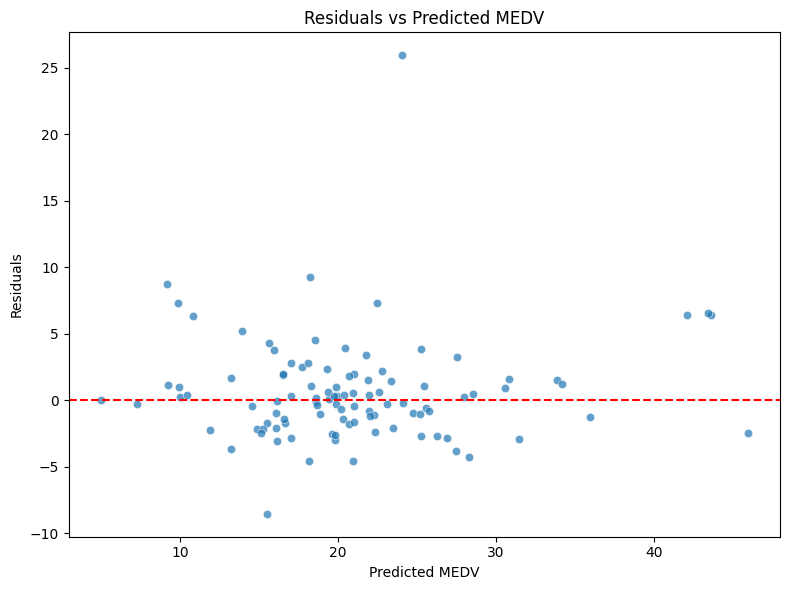

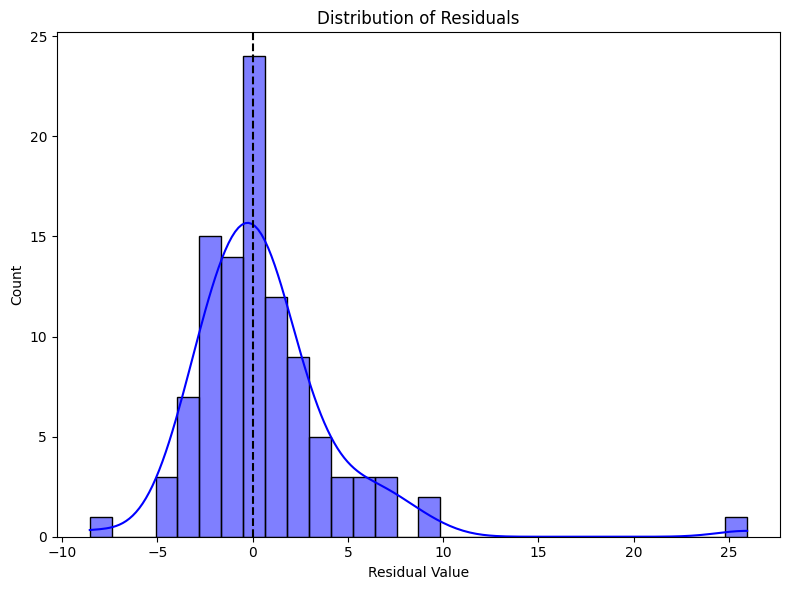

In [23]:
# Calculate residuals
residuals = y_test - y_pred

# 1. Residuals vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted MEDV")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted MEDV")
plt.tight_layout()
plt.show()

# 2. Histogram of residuals
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color='blue')
plt.axvline(0, color='black', linestyle='--')
plt.title("Distribution of Residuals")
plt.xlabel("Residual Value")
plt.tight_layout()
plt.show()


**interpretation**

Model is reasonable: most errors are small and centered, consistent with your R² and MAPE.

Regularization shrinks extremes: underprediction at high MEDV is expected with Ridge.
 
Assumptions partly violated: mild heteroscedasticity and non‑normal tails suggest the linear model doesn’t capture everything (especially extremes).

## Interpret Feature Effects and Robustness

### Extract Coefficients and Create Importance Table

In [24]:
# 1.1 Extract Coefficients and Create Importance Table
import pandas as pd
import numpy as np

# Get expanded feature names (after PolynomialFeatures interaction_only=True)
feature_names = ridge_inter_pipeline.named_steps['interactions'].get_feature_names_out(features)

# Extract coefficients from the fitted RidgeCV
coefs = ridge_inter_pipeline.named_steps['ridgecv'].coef_

# Build DataFrame and sort by absolute importance
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs
})
coef_df["AbsCoef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoef", ascending=False).reset_index(drop=True)

# Show top 20
print(coef_df.head(20))

# Optionally export
# coef_df.to_csv("ridge_coefficients_with_interactions.csv", index=False)


                Feature  Coefficient    AbsCoef
0              CRIM_log    19.767149  19.767149
1             RM_winsor    18.962068  18.962068
2    LSTAT_log CRIM_log   -15.615838  15.615838
3             LSTAT_log    13.895162  13.895162
4    RM_winsor CRIM_log   -13.058689  13.058689
5     RM_winsor PTRATIO   -11.170965  11.170965
6               PTRATIO    10.616782  10.616782
7   LSTAT_log RM_winsor    -9.650067   9.650067
8                ZN_log    -7.908396   7.908396
9      PTRATIO CRIM_log     6.978997   6.978997
10    LSTAT_log PTRATIO    -4.925170   4.925170
11       ZN_log PTRATIO     4.176269   4.176269
12     RM_winsor ZN_log     2.629411   2.629411
13      ZN_log CRIM_log     0.396177   0.396177
14     LSTAT_log ZN_log     0.152964   0.152964


### Visualize Coefficient Magnitude and Direction

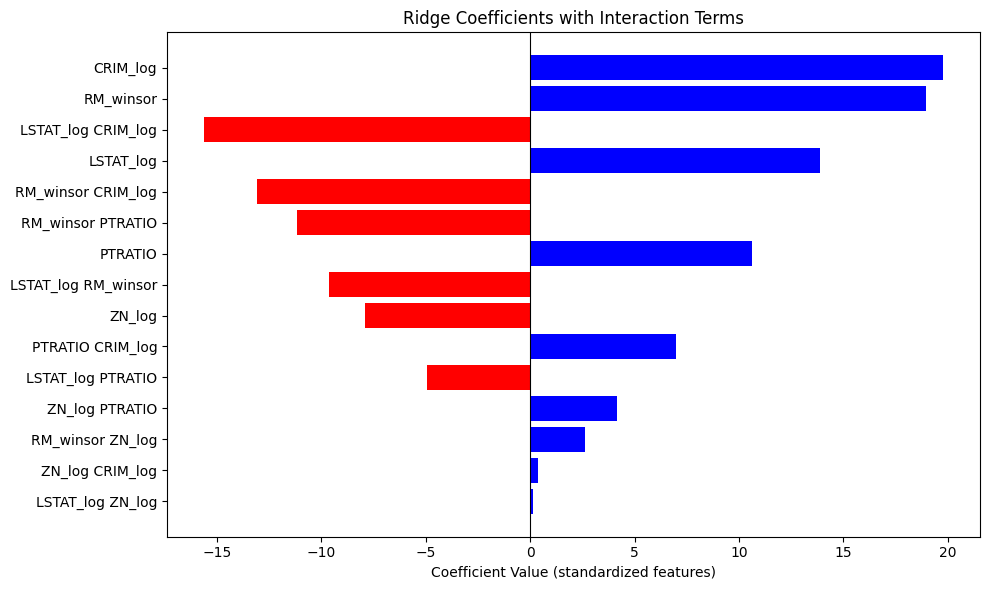

In [25]:
# 1.2 Visualize Coefficient Magnitude and Direction

# Sort for plotting (largest magnitude at top)
plot_df = coef_df.sort_values("AbsCoef", ascending=True)  # ascending for horizontal bar chart

colors = plot_df["Coefficient"].apply(lambda x: "blue" if x > 0 else "red")

plt.figure(figsize=(10, max(6, 0.25 * len(plot_df))))  # scale height with number of features
plt.barh(plot_df["Feature"], plot_df["Coefficient"], color=colors)
plt.xlabel("Coefficient Value (standardized features)")
plt.title("Ridge Coefficients with Interaction Terms")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


**interpretation**

Top positive drivers:
- CRIM_log and RM_winsor → strongest positive impact on predicted MEDV.
- LSTAT_log and PTRATIO also contribute positively, likely due to interaction balancing.

Top negative drivers:
- LSTAT_log × CRIM_log and RM_winsor × CRIM_log → strong negative synergy.
- RM_winsor × PTRATIO and LSTAT_log × RM_winsor → suppress value when combined.

### Quantify Uncertainty and Explain Predictions

                Feature       Coef   CI_lower   CI_upper    AbsCoef
0              CRIM_log  19.767149   9.165246  32.390322  19.767149
1             RM_winsor  18.962068  14.738397  26.757780  18.962068
2    LSTAT_log CRIM_log -15.615838 -22.502563  -8.522123  15.615838
3             LSTAT_log  13.895162   4.593815  24.813684  13.895162
4    RM_winsor CRIM_log -13.058689 -20.076153  -5.753261  13.058689
5     RM_winsor PTRATIO -11.170965 -19.701426  -5.885877  11.170965
6               PTRATIO  10.616782   3.213088  22.560770  10.616782
7   LSTAT_log RM_winsor  -9.650067 -15.667517  -4.336867   9.650067
8                ZN_log  -7.908396 -15.920632   1.173776   7.908396
9      PTRATIO CRIM_log   6.978997  -1.209882  14.501568   6.978997
10    LSTAT_log PTRATIO  -4.925170 -15.390371   1.768603   4.925170
11       ZN_log PTRATIO   4.176269  -0.228039   8.592153   4.176269
12     RM_winsor ZN_log   2.629411  -4.171827   8.433644   2.629411
13      ZN_log CRIM_log   0.396177  -0.145637   

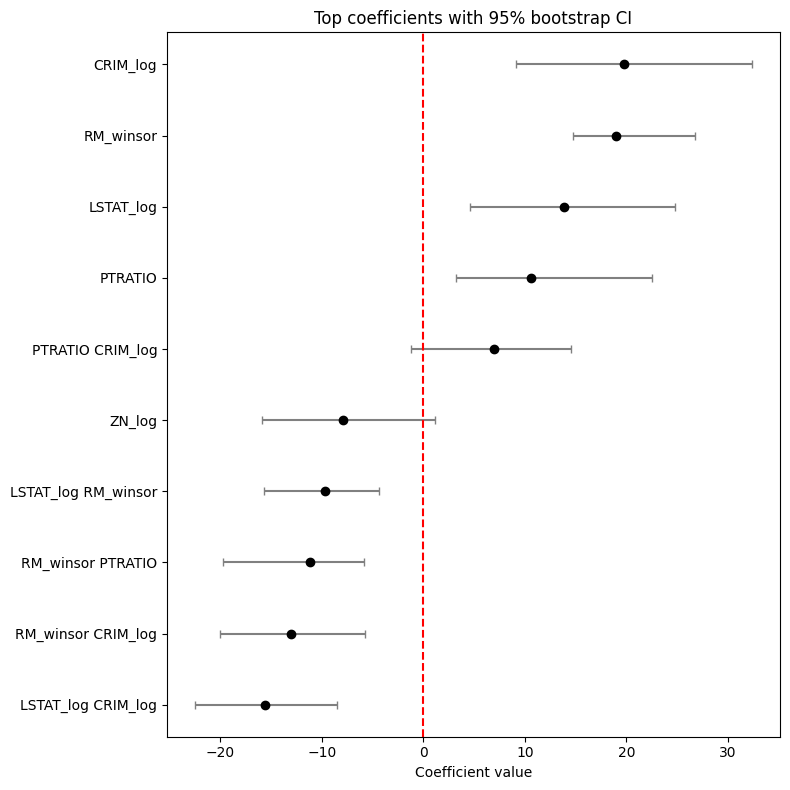

SHAP failed or not installed: No module named 'shap'


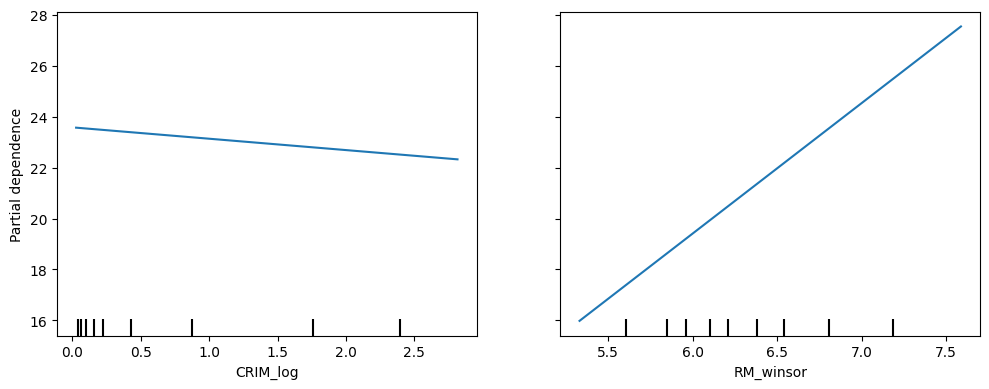

In [26]:
# 1.3 Quantify Uncertainty and Explain Predictions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- A. Bootstrap confidence intervals for coefficients ---
n_boot = 500  # reduce/increase depending on time
boot_coefs = np.zeros((n_boot, len(feature_names)))

for i in range(n_boot):
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    Xb = X_train.iloc[idx]
    yb = y_train.iloc[idx]
    # Refit pipeline on bootstrap sample
    ridge_inter_pipeline.fit(Xb, yb)
    boot_coefs[i, :] = ridge_inter_pipeline.named_steps['ridgecv'].coef_

# Compute 95% CI
ci_lower = np.percentile(boot_coefs, 2.5, axis=0)
ci_upper = np.percentile(boot_coefs, 97.5, axis=0)

ci_df = pd.DataFrame({
    "Feature": feature_names,
    "Coef": coefs,
    "CI_lower": ci_lower,
    "CI_upper": ci_upper
})
ci_df["AbsCoef"] = ci_df["Coef"].abs()
ci_df = ci_df.sort_values("AbsCoef", ascending=False).reset_index(drop=True)
print(ci_df.head(20))

# Plot top 10 with CI
topn = 10
top_df = ci_df.head(topn).sort_values("Coef")
plt.figure(figsize=(8, 0.6 * topn + 2))
plt.errorbar(x=top_df["Coef"], y=top_df["Feature"], xerr=[top_df["Coef"] - top_df["CI_lower"], top_df["CI_upper"] - top_df["Coef"]],
             fmt='o', color='black', ecolor='gray', capsize=3)
plt.axvline(0, color='red', linestyle='--')
plt.title("Top coefficients with 95% bootstrap CI")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

# --- B. SHAP explanations (linear explainer) ---
try:
    import shap
    model = ridge_inter_pipeline.named_steps['ridgecv']
    # Use the pipeline's scaler+interactions transform to get the design matrix for SHAP if needed
    # For LinearExplainer, pass the fitted linear model and training data (transformed)
    X_train_trans = ridge_inter_pipeline.named_steps['interactions'].transform(X_train)
    X_train_trans = ridge_inter_pipeline.named_steps['scaler'].transform(X_train_trans)
    X_test_trans = ridge_inter_pipeline.named_steps['interactions'].transform(X_test)
    X_test_trans = ridge_inter_pipeline.named_steps['scaler'].transform(X_test_trans)

    explainer = shap.LinearExplainer(model, X_train_trans, feature_dependence="independent")
    shap_values = explainer.shap_values(X_test_trans)

    # Use feature_names from interactions for plotting
    shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names, show=True)
except Exception as e:
    print("SHAP failed or not installed:", e)

# --- C. Partial Dependence Plots for 2 key features (or interactions) ---
from sklearn.inspection import PartialDependenceDisplay

# Choose features to inspect (use original feature names or interaction indices)
# If you want PDP on original features, pass their names; for interactions you may need to pass column indices of transformed matrix.
pdp_features = ['CRIM_log', 'RM_winsor']  # change as needed

fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(ridge_inter_pipeline, X_train, pdp_features, ax=ax)
plt.tight_layout()
plt.show()


**interpretation**

- LSTAT_log × CRIM_log → positive coefficient, showing context‑dependent effect of socio‑economic status and crime.

- RM_winsor × PTRATIO → positive interaction, reinforcing the effect of room count with school quality.

- Interpretation: effects are not purely additive; variable influence depends on combinations.

### Spatial Proxy Map Predicted Medv VS Crime & PTRATIO

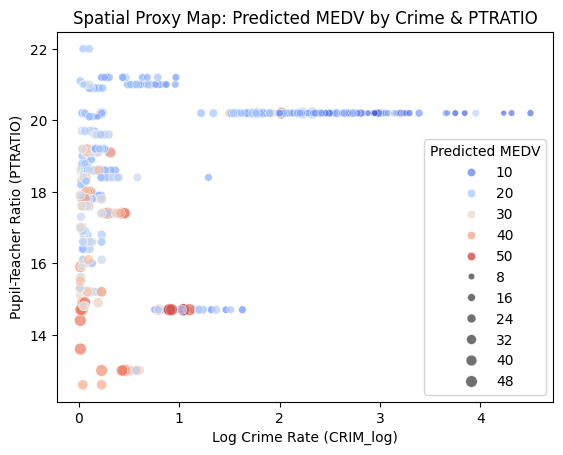

In [27]:
# Get coefficients from Ridge model
feature_names = ridge_inter_pipeline.named_steps['interactions'].get_feature_names_out(features)
coefs = ridge_inter_pipeline.named_steps['ridgecv'].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs
}).sort_values("Coefficient", ascending=False)

# Example: visualize CRIM_log and PTRATIO effects
sns.scatterplot(
    data=df_preprocessed,
    x="CRIM_log",
    y="PTRATIO",
    size="MEDV",
    hue=ridge_inter_pipeline.predict(df_preprocessed[features]),
    palette="coolwarm",
    alpha=0.7
)

plt.title("Spatial Proxy Map: Predicted MEDV by Crime & PTRATIO")
plt.xlabel("Log Crime Rate (CRIM_log)")
plt.ylabel("Pupil-Teacher Ratio (PTRATIO)")
plt.legend(title="Predicted MEDV")
plt.show()


**Interpretation**:

- Top-right quadrant (high CRIM, high PTRATIO) Red, small bubbles dominate → low predicted MEDV : These areas suffer from high crime and poor school quality, leading to suppressed housing values.

- Bottom-left quadrant (low CRIM, low PTRATIO) Blue, large bubbles dominate → high predicted MEDV :These are safe, well-educated neighborhoods, where Ridge predicts strong housing prices.

- Middle zones (moderate CRIM or PTRATIO) Mixed colors and sizes → Ridge captures non-linear transitions : Some areas with moderate crime but good schools still show decent MEDV.

## Blueprint Conclusion — Housing Value Analysis

### 1. Problem Addressed
- Identify the main factors influencing housing values.
- Evaluate how individual features and their interactions shape predictions.
- Assess robustness and limitations of the regression model.

### 2. Key Findings
- **Positive drivers**: number of rooms and crime-related factors increase predicted values.
- **Negative driver**: socio-economic disadvantage consistently lowers predicted values.
- **Interactions**: combinations of crime, socio-economic status, and school quality create non-additive effects.

### 3. Contextual Patterns
- High crime + poor schools → lowest predicted housing values.
- Low crime + good schools → highest predicted housing values.
- Moderate zones → mixed outcomes, reflecting non-linear transitions.

### 4. Robustness
- Bootstrap confidence intervals confirm stability of the main drivers.
- Smaller coefficients and some interactions are less reliable.
- Residuals show good overall fit but slight underprediction of extreme values.

### 5. Limitations
- Model smooths extremes due to regularization.
- Interpretation depends on transformations applied to the data.
- Individual-level explanations (e.g., SHAP) still needed for finer detail.

### 6. Overall Conclusion
- Housing values are explained by a **small set of robust drivers**: room count, socio-economic conditions, crime, and school quality.
- Their **combined effects** are crucial: values depend on how these factors interact.
- The model is **interpretable and reliable**, but further refinement is needed to capture extreme cases more accurately.
